In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
from torchvision.models import Inception_V3_Weights

# Load ImageNet class labels from torchvision model metadata
imagenet_weights = Inception_V3_Weights.IMAGENET1K_V1
IMAGENET_CATEGORIES = imagenet_weights.meta['categories']

def get_class_names(indices):
    """Get class names from ImageNet indices using torchvision metadata"""
    return [IMAGENET_CATEGORIES[i] for i in indices]

# Base path for all experiments
BASE_PATH = r"C:\git\PhysicalAdverserialProj\total_experiments_analysis"

# Model definitions
V1_MODELS = ['v1_inception', 'v1_resnet', 'v1_vgg', 'v1_vit']  # Seen (trained on)
V2_MODELS = ['v2_convnext', 'v2_efficientnet', 'v2_mobilenet', 'v2_swin']  # Unseen
DINO_MODEL = 'dino_standalone'

# Approaches to analyze
APPROACHES = ['Baseline_Noise', 'CAPAA', 'Patch']

# Experiment configurations based on consts.py class indices
# Class names are fetched dynamically from torchvision model metadata
EXPERIMENTS = {
    'cup': {
        'main_folder': 'cup_experiment_results_2026-01-14_13_28_29',
        'baseline_noise_folder': None,
        'forbidden_indices': [504, 968, 899],
        'forbidden_classes': get_class_names([504, 968, 899])
    },
    'paper_towel': {
        'main_folder': 'paper_towel_experiment_results_2026-01-13_12_26_34',
        'baseline_noise_folder': 'paper_towel_experiment_results_2026-01-14_00_39_17',
        'forbidden_indices': [700, 999],
        'forbidden_classes': get_class_names([700, 999])
    },
    'purse': {
        'main_folder': 'purse_experiment_results_2026-01-13_23_51_08',
        'baseline_noise_folder': None,
        'forbidden_indices': [636, 414, 748],
        'forbidden_classes': get_class_names([636, 414, 748])
    },
    'jeep': {
        'main_folder': 'jeep_experiment_results_2025-12-28_18_09_06',
        'baseline_noise_folder': 'experiment_results_2026-01-17_16_31_51',
        'baseline_noise_base_path': r'C:\git\PhysicalAdverserialProj\paper_experiments',
        'forbidden_indices': [817, 705, 609, 586, 436, 627, 468, 621, 803, 407, 408, 751, 717, 866, 661, 864],
        'forbidden_classes': get_class_names([817, 705, 609, 586, 436, 627, 468, 621, 803, 407, 408, 751, 717, 866, 661, 864]),
        # Hardcoded pixel change values (no pixel_change_analysis.csv for old experiment)
        'hardcoded_pixel': {'CAPAA': 15.3, 'Patch': 3.4}
    },
    'guitar': {
        'main_folder': 'experiment_results_2026-01-16_00_03_32',
        'base_path': r'C:\git\PhysicalAdverserialProj\paper_experiments',
        'baseline_noise_folder': None,
        'forbidden_indices': [420, 402, 546, 889],
        'forbidden_classes': get_class_names([420, 402, 546, 889])
    }
}

print(f"Experiments to analyze: {list(EXPERIMENTS.keys())}")
print(f"V1 Models (Seen): {V1_MODELS}")
print(f"V2 Models (Unseen): {V2_MODELS}")
print(f"\nForbidden classes (from torchvision metadata):")

for exp, cfg in EXPERIMENTS.items():    print(f"  {exp}: {cfg['forbidden_classes']}")

Experiments to analyze: ['cup', 'paper_towel', 'purse', 'jeep', 'guitar']
V1 Models (Seen): ['v1_inception', 'v1_resnet', 'v1_vgg', 'v1_vit']
V2 Models (Unseen): ['v2_convnext', 'v2_efficientnet', 'v2_mobilenet', 'v2_swin']

Forbidden classes (from torchvision metadata):
  cup: ['coffee mug', 'cup', 'water jug']
  paper_towel: ['paper towel', 'toilet tissue']
  purse: ['mailbag', 'backpack', 'purse']
  jeep: ['sports car', 'passenger car', 'jeep', 'half track', 'beach wagon', 'limousine', 'cab', 'lawn mower', 'snowplow', 'ambulance', 'amphibian', 'racer', 'pickup', 'tractor', 'Model T', 'tow truck']
  guitar: ['banjo', 'acoustic guitar', 'electric guitar', 'violin']


In [4]:
def load_experiment_data(exp_name, exp_config):
    """Load data for a single experiment, combining main and baseline_noise if needed"""
    # Use custom base_path if provided, otherwise use global BASE_PATH
    base_path = exp_config.get('base_path', BASE_PATH)
    main_path = os.path.join(base_path, exp_config['main_folder'], 'data', 'raw_predictions.csv')
    
    if not os.path.exists(main_path):
        print(f"  Warning: {main_path} not found")
        return None
    
    df = pd.read_csv(main_path)
    print(f"  {exp_name}: Loaded {len(df)} predictions from main")
    
    # Load baseline_noise from separate folder if specified
    if exp_config.get('baseline_noise_folder'):
        bn_base_path = exp_config.get('baseline_noise_base_path', base_path)
        bn_path = os.path.join(bn_base_path, exp_config['baseline_noise_folder'], 'data', 'raw_predictions.csv')
        if os.path.exists(bn_path):
            df_bn = pd.read_csv(bn_path)
            df_bn = df_bn[df_bn['approach'] == 'Baseline_Noise']
            df = pd.concat([df, df_bn], ignore_index=True)
            print(f"  {exp_name}: Added {len(df_bn)} baseline_noise predictions")
        else:
            print(f"  Warning: {bn_path} not found")
    
    # Calculate success based on forbidden classes
    forbidden = exp_config['forbidden_classes']
    df['success'] = ~df['predicted_class'].isin(forbidden)
    
    return df

def load_pixel_change_data(exp_name, exp_config):
    """Load pixel change analysis data for an experiment, including SE"""
    # Use custom base_path if provided, otherwise use global BASE_PATH
    base_path = exp_config.get('base_path', BASE_PATH)
    main_path = os.path.join(base_path, exp_config['main_folder'], 'data', 'pixel_change_analysis.csv')
    
    pixel_data = {}
    pixel_se_data = {}
    
    # Use hardcoded pixel values if provided (for experiments without pixel_change_analysis.csv)
    if 'hardcoded_pixel' in exp_config:
        for approach, val in exp_config['hardcoded_pixel'].items():
            pixel_data[approach] = val
            pixel_se_data[approach] = 0.0  # No SE for hardcoded values
        print(f"  {exp_name}: Using hardcoded pixel values: {exp_config['hardcoded_pixel']}")
    
    if os.path.exists(main_path):
        df = pd.read_csv(main_path)
        # Calculate mean and SE of pixel change percentage per approach
        for approach in df['approach'].unique():
            approach_data = df[df['approach'] == approach]
            pixel_data[approach] = approach_data['pixel_change_pct'].mean()
            n = len(approach_data)
            if n > 1:
                pixel_se_data[approach] = approach_data['pixel_change_pct'].std(ddof=1) / np.sqrt(n)
            else:
                pixel_se_data[approach] = 0.0
        print(f"  {exp_name}: Loaded pixel change data ({len(df)} entries)")
    
    # Load baseline_noise pixel data from separate folder if specified
    if exp_config.get('baseline_noise_folder'):
        bn_base_path = exp_config.get('baseline_noise_base_path', base_path)
        bn_path = os.path.join(bn_base_path, exp_config['baseline_noise_folder'], 'data', 'pixel_change_analysis.csv')
        if os.path.exists(bn_path):
            df_bn = pd.read_csv(bn_path)
            df_bn = df_bn[df_bn['approach'] == 'Baseline_Noise']
            if len(df_bn) > 0:
                pixel_data['Baseline_Noise'] = df_bn['pixel_change_pct'].mean()
                n = len(df_bn)
                if n > 1:
                    pixel_se_data['Baseline_Noise'] = df_bn['pixel_change_pct'].std(ddof=1) / np.sqrt(n)
                else:
                    pixel_se_data['Baseline_Noise'] = 0.0
                print(f"  {exp_name}: Added baseline_noise pixel data ({len(df_bn)} entries)")
    
    # Baseline has 0% pixel change (no projection)
    if 'Baseline' not in pixel_data:
        pixel_data['Baseline'] = 0.0
        pixel_se_data['Baseline'] = 0.0
    
    return (pixel_data, pixel_se_data) if pixel_data else (None, None)

# Load all experiments
print("Loading all experiments...")
all_data = {}
all_pixel_data = {}
all_pixel_se_data = {}
for exp_name, exp_config in EXPERIMENTS.items():
    df = load_experiment_data(exp_name, exp_config)
    if df is not None:
        all_data[exp_name] = df
        print(f"  {exp_name}: {df['approach'].unique()}")
    
    # Load pixel change data (with SE)
    pixel_data, pixel_se_data = load_pixel_change_data(exp_name, exp_config)
    if pixel_data:
        all_pixel_data[exp_name] = pixel_data
        all_pixel_se_data[exp_name] = pixel_se_data

print(f"\nLoaded {len(all_data)} experiments successfully")
print(f"Pixel change data available for: {list(all_pixel_data.keys())}")

Loading all experiments...
  cup: Loaded 48000 predictions from main
  cup: ['Baseline' 'Baseline_Noise' 'CAPAA' 'Patch_rejuv' 'Patch']
  cup: Loaded pixel change data (175 entries)
  paper_towel: Loaded 42000 predictions from main
  paper_towel: Added 6000 baseline_noise predictions
  paper_towel: ['Baseline' 'CAPAA' 'Patch_rejuv' 'Patch' 'Baseline_Noise']
  paper_towel: Loaded pixel change data (150 entries)
  paper_towel: Added baseline_noise pixel data (25 entries)
  purse: Loaded 48000 predictions from main
  purse: ['Baseline' 'Baseline_Noise' 'CAPAA' 'Patch_rejuv' 'Patch']
  purse: Loaded pixel change data (175 entries)
  jeep: Loaded 198000 predictions from main
  jeep: Added 6000 baseline_noise predictions
  jeep: ['CAPAA' 'Patch_rejuv' 'Patch' 'Baseline_Noise']
  jeep: Using hardcoded pixel values: {'CAPAA': 15.3, 'Patch': 3.4}
  jeep: Added baseline_noise pixel data (25 entries)
  guitar: Loaded 46800 predictions from main
  guitar: ['Baseline' 'Baseline_Noise' 'CAPAA' 'Patc

In [5]:
def calc_se(data):
    """Calculate standard error of the mean"""
    if len(data) == 0:
        return np.nan
    return np.std(data, ddof=1) / np.sqrt(len(data)) * 100  # Convert to percentage

def build_condensed_table(df, approaches, v1_models, v2_models, dino_model, pixel_data=None, pixel_se_data=None):
    """Build condensed table with individual models, group averages, standard errors, and pixel change"""
    results = []
    
    for approach in approaches:
        if approach not in df['approach'].unique():
            continue
        
        row = {'Method': approach}
        
        # Pixel change percentage (if available)
        if pixel_data and approach in pixel_data:
            row['Pixel%'] = pixel_data[approach]
            row['Pixel_SE'] = pixel_se_data.get(approach, np.nan) if pixel_se_data else np.nan
        else:
            row['Pixel%'] = np.nan
            row['Pixel_SE'] = np.nan
        
        # V1 individual models
        v1_rates = []
        for model in v1_models:
            model_data = df[(df['approach'] == approach) & (df['model'] == model)]
            rate = model_data['success'].mean() * 100 if len(model_data) > 0 else np.nan
            se = calc_se(model_data['success']) if len(model_data) > 0 else np.nan
            row[model.replace('v1_', 'V1-')] = rate
            row[model.replace('v1_', 'V1-') + '_SE'] = se
            if not np.isnan(rate):
                v1_rates.append(rate)
        row['V1-Avg'] = np.mean(v1_rates) if v1_rates else np.nan
        row['V1-Avg_SE'] = np.std(v1_rates) / np.sqrt(len(v1_rates)) if len(v1_rates) > 0 else np.nan
        
        # DINO
        dino_data = df[(df['approach'] == approach) & (df['model'] == dino_model)]
        row['DINO'] = dino_data['success'].mean() * 100 if len(dino_data) > 0 else np.nan
        row['DINO_SE'] = calc_se(dino_data['success']) if len(dino_data) > 0 else np.nan
        
        # V2 individual models
        v2_rates = []
        for model in v2_models:
            model_data = df[(df['approach'] == approach) & (df['model'] == model)]
            rate = model_data['success'].mean() * 100 if len(model_data) > 0 else np.nan
            se = calc_se(model_data['success']) if len(model_data) > 0 else np.nan
            row[model.replace('v2_', 'V2-')] = rate
            row[model.replace('v2_', 'V2-') + '_SE'] = se
            if not np.isnan(rate):
                v2_rates.append(rate)
        row['V2-Avg'] = np.mean(v2_rates) if v2_rates else np.nan
        row['V2-Avg_SE'] = np.std(v2_rates) / np.sqrt(len(v2_rates)) if len(v2_rates) > 0 else np.nan
        
        results.append(row)
    
    table = pd.DataFrame(results)
    col_order = ['Method', 'Pixel%', 'Pixel_SE',
                 'V1-inception', 'V1-inception_SE', 'V1-resnet', 'V1-resnet_SE', 
                 'V1-vgg', 'V1-vgg_SE', 'V1-vit', 'V1-vit_SE', 'V1-Avg', 'V1-Avg_SE',
                 'DINO', 'DINO_SE',
                 'V2-convnext', 'V2-convnext_SE', 'V2-efficientnet', 'V2-efficientnet_SE', 
                 'V2-mobilenet', 'V2-mobilenet_SE', 'V2-swin', 'V2-swin_SE', 'V2-Avg', 'V2-Avg_SE']
    return table[[c for c in col_order if c in table.columns]]

# Build condensed tables for all experiments
all_tables = {}
for exp_name, df in all_data.items():
    # For jeep, only use CAPAA and Patch (no baseline)
    approaches_to_use = ['CAPAA', 'Patch'] if EXPERIMENTS[exp_name].get('no_baseline') else APPROACHES
    pixel_data = all_pixel_data.get(exp_name, None)
    pixel_se_data = all_pixel_se_data.get(exp_name, None)
    all_tables[exp_name] = build_condensed_table(df, approaches_to_use, V1_MODELS, V2_MODELS, DINO_MODEL, pixel_data, pixel_se_data)
    print(f"\n{exp_name.upper()} (Forbidden: {EXPERIMENTS[exp_name]['forbidden_classes']})")
    # Print condensed table (without SE columns for display)
    display_cols = [c for c in all_tables[exp_name].columns if not c.endswith('_SE')]
    print(all_tables[exp_name][display_cols].to_string(index=False))


CUP (Forbidden: ['coffee mug', 'cup', 'water jug'])
        Method    Pixel%  V1-inception  V1-resnet  V1-vgg  V1-vit  V1-Avg  DINO  V2-convnext  V2-efficientnet  V2-mobilenet  V2-swin  V2-Avg
Baseline_Noise 59.104072           3.6       35.2     9.4     0.0  12.050   0.0          0.0             20.0          20.0      1.4  10.350
         CAPAA  3.606174           0.8       85.0    75.8    31.1  48.175   5.6         62.1             53.6          60.8     62.2  59.675
         Patch  2.905333          35.7      100.0    80.0    28.7  61.100  50.2         17.7             94.9          79.7     40.1  58.100

PAPER_TOWEL (Forbidden: ['paper towel', 'toilet tissue'])
        Method    Pixel%  V1-inception  V1-resnet  V1-vgg  V1-vit  V1-Avg  DINO  V2-convnext  V2-efficientnet  V2-mobilenet  V2-swin  V2-Avg
Baseline_Noise 62.434197          27.2       39.4    70.4     7.2   36.05   8.0          0.0              2.2          87.4      1.0  22.650
         CAPAA  4.268338         100.0    

In [6]:
# Color gradient function
def color_gradient(val):
    """Color gradient from red (low) to green (high)"""
    if pd.isna(val) or isinstance(val, str):
        return ''
    normalized = val / 100
    if normalized < 0.5:
        r = 255
        g = int(255 * (normalized * 2))
    else:
        r = int(255 * (2 - normalized * 2))
        g = 255
    b = 50
    return f'background-color: rgba({r},{g},{b},0.7); color: black; font-weight: bold'

def format_with_se(table):
    """Format table values with ± SE for display"""
    display_table = pd.DataFrame()
    display_table['Method'] = table['Method']
    
    # Value columns and their SE counterparts
    value_cols = ['Pixel%', 'V1-inception', 'V1-resnet', 'V1-vgg', 'V1-vit', 'V1-Avg',
                  'DINO', 'V2-convnext', 'V2-efficientnet', 'V2-mobilenet', 'V2-swin', 'V2-Avg']
    
    for col in value_cols:
        if col in table.columns:
            se_col = col + '_SE' if col != 'Pixel%' else 'Pixel_SE'
            if se_col in table.columns:
                # Format as "value ± SE"
                formatted = []
                for _, row in table.iterrows():
                    val = row[col]
                    se = row.get(se_col, np.nan)
                    if pd.isna(val):
                        formatted.append('N/A')
                    elif pd.isna(se) or se == 0:
                        formatted.append(f'{val:.1f}')
                    else:
                        formatted.append(f'{val:.1f}±{se:.1f}')
                display_table[col] = formatted
            else:
                display_table[col] = table[col].apply(lambda x: f'{x:.1f}' if not pd.isna(x) else 'N/A')
    
    return display_table

# Display all styled tables with ± SE
for exp_name, table in all_tables.items():
    print(f"\n{'='*80}")
    print(f"{exp_name.upper()} - Forbidden: {EXPERIMENTS[exp_name]['forbidden_classes']}")
    print(f"{'='*80}")
    
    # Create display table with SE values formatted
    display_table = format_with_se(table)
    
    # Display as styled HTML
    print(display_table.to_string(index=False))


CUP - Forbidden: ['coffee mug', 'cup', 'water jug']
        Method   Pixel% V1-inception V1-resnet   V1-vgg   V1-vit    V1-Avg     DINO V2-convnext V2-efficientnet V2-mobilenet  V2-swin    V2-Avg
Baseline_Noise 59.1±1.4      3.6±0.8  35.2±2.1  9.4±1.3      0.0  12.0±6.9      0.0         0.0        20.0±1.8     20.0±1.8  1.4±0.5  10.3±4.8
         CAPAA  3.6±0.3      0.8±0.3  85.0±1.1 75.8±1.4 31.1±1.5 48.2±17.1  5.6±0.7    62.1±1.5        53.6±1.6     60.8±1.5 62.2±1.5  59.7±1.8
         Patch  2.9±0.3     35.7±1.5     100.0 80.0±1.3 28.7±1.4 61.1±14.9 50.2±1.6    17.7±1.2        94.9±0.7     79.7±1.3 40.1±1.6 58.1±15.4

PAPER_TOWEL - Forbidden: ['paper towel', 'toilet tissue']
        Method   Pixel% V1-inception V1-resnet   V1-vgg   V1-vit    V1-Avg     DINO V2-convnext V2-efficientnet V2-mobilenet  V2-swin    V2-Avg
Baseline_Noise 62.4±2.3     27.2±2.0  39.4±2.2 70.4±2.0  7.2±1.2 36.0±11.5  8.0±1.2         0.0         2.2±0.7     87.4±1.5  1.0±0.4 22.7±18.7
         CAPAA  4.3±0.1 

In [7]:
# Generate LaTeX table with winning method in bold and ± SE
def generate_latex_table(all_tables, experiments_config):
    """Generate LaTeX table with bold winners and standard errors"""
    
    # Combine all experiments into one summary table
    latex_rows = []
    
    # Define metrics for comparison
    metrics = ['Pixel%', 'V1-Avg', 'DINO', 'V2-Avg']
    se_cols = ['Pixel_SE', 'V1-Avg_SE', 'DINO_SE', 'V2-Avg_SE']
    
    for exp_name, table in all_tables.items():
        # Find winners for each metric (lower is better for Pixel%, higher for others)
        winners = {}
        for metric in metrics:
            if metric not in table.columns:
                continue
            
            valid_vals = table[['Method', metric]].dropna(subset=[metric])
            if len(valid_vals) == 0:
                continue
            
            if metric == 'Pixel%':
                # Lower is better
                best_idx = valid_vals[metric].idxmin()
            else:
                # Higher is better
                best_idx = valid_vals[metric].idxmax()
            
            winners[metric] = valid_vals.loc[best_idx, 'Method']
        
        # Build rows
        for _, row in table.iterrows():
            method = row['Method']
            row_data = {
                'Experiment': exp_name.replace('_', ' ').title(),
                'Method': method
            }
            
            for metric, se_col in zip(metrics, se_cols):
                if metric in row:
                    val = row[metric]
                    se = row.get(se_col, np.nan) if se_col in row else np.nan
                    if pd.isna(val):
                        row_data[metric] = '--'
                    else:
                        # Format value ± SE
                        if pd.isna(se) or se == 0:
                            val_str = f'{val:.1f}'
                        else:
                            val_str = f'{val:.1f}$\\pm${se:.1f}'
                        # Bold if winner
                        if winners.get(metric) == method:
                            val_str = f'\\textbf{{{val_str}}}'
                        row_data[metric] = val_str
                else:
                    row_data[metric] = '--'
            
            latex_rows.append(row_data)
    
    # Create DataFrame
    latex_df = pd.DataFrame(latex_rows)
    
    # Generate LaTeX code
    latex_code = """\\begin{table}[htbp]
\\centering
\\caption{Attack Success Rate (\\%) Comparison Across Experiments (Mean $\\pm$ SE). \\textbf{Bold} indicates best method per experiment. For Pixel\\%, lower is better (less visible attack). For success rates, higher is better.}
\\label{tab:attack_comparison}
\\begin{tabular}{llcccc}
\\toprule
\\textbf{Experiment} & \\textbf{Method} & \\textbf{Pixel\\%} $\\downarrow$ & \\textbf{V1-Avg} $\\uparrow$ & \\textbf{DINO} $\\uparrow$ & \\textbf{V2-Avg} $\\uparrow$ \\\\
\\midrule
"""
    
    current_exp = None
    for _, row in latex_df.iterrows():
        exp = row['Experiment']
        if exp != current_exp:
            if current_exp is not None:
                latex_code += "\\midrule\n"
            current_exp = exp
        
        latex_code += f"{exp} & {row['Method']} & {row['Pixel%']} & {row['V1-Avg']} & {row['DINO']} & {row['V2-Avg']} \\\\\n"
    
    latex_code += """\\bottomrule
\\end{tabular}
\\end{table}"""
    
    return latex_code, latex_df

# Generate and display LaTeX
latex_code, latex_df = generate_latex_table(all_tables, EXPERIMENTS)

print("="*100)
print("LATEX TABLE CODE (Copy for paper)")
print("="*100)
print(latex_code)

print("\n" + "="*100)
print("Preview DataFrame:")
print("="*100)
print(latex_df.to_string(index=False))

LATEX TABLE CODE (Copy for paper)
\begin{table}[htbp]
\centering
\caption{Attack Success Rate (\%) Comparison Across Experiments (Mean $\pm$ SE). \textbf{Bold} indicates best method per experiment. For Pixel\%, lower is better (less visible attack). For success rates, higher is better.}
\label{tab:attack_comparison}
\begin{tabular}{llcccc}
\toprule
\textbf{Experiment} & \textbf{Method} & \textbf{Pixel\%} $\downarrow$ & \textbf{V1-Avg} $\uparrow$ & \textbf{DINO} $\uparrow$ & \textbf{V2-Avg} $\uparrow$ \\
\midrule
Cup & Baseline_Noise & 59.1$\pm$1.4 & 12.0$\pm$6.9 & 0.0 & 10.3$\pm$4.8 \\
Cup & CAPAA & 3.6$\pm$0.3 & 48.2$\pm$17.1 & 5.6$\pm$0.7 & \textbf{59.7$\pm$1.8} \\
Cup & Patch & \textbf{2.9$\pm$0.3} & \textbf{61.1$\pm$14.9} & \textbf{50.2$\pm$1.6} & 58.1$\pm$15.4 \\
\midrule
Paper Towel & Baseline_Noise & 62.4$\pm$2.3 & 36.0$\pm$11.5 & 8.0$\pm$1.2 & 22.7$\pm$18.7 \\
Paper Towel & CAPAA & 4.3$\pm$0.1 & 83.8$\pm$8.2 & 16.4$\pm$1.2 & 69.8$\pm$16.6 \\
Paper Towel & Patch & \textbf{1.2$\p

Paper figures will be saved to: C:\git\PhysicalAdverserialProj\total_experiments_analysis\paper_figures


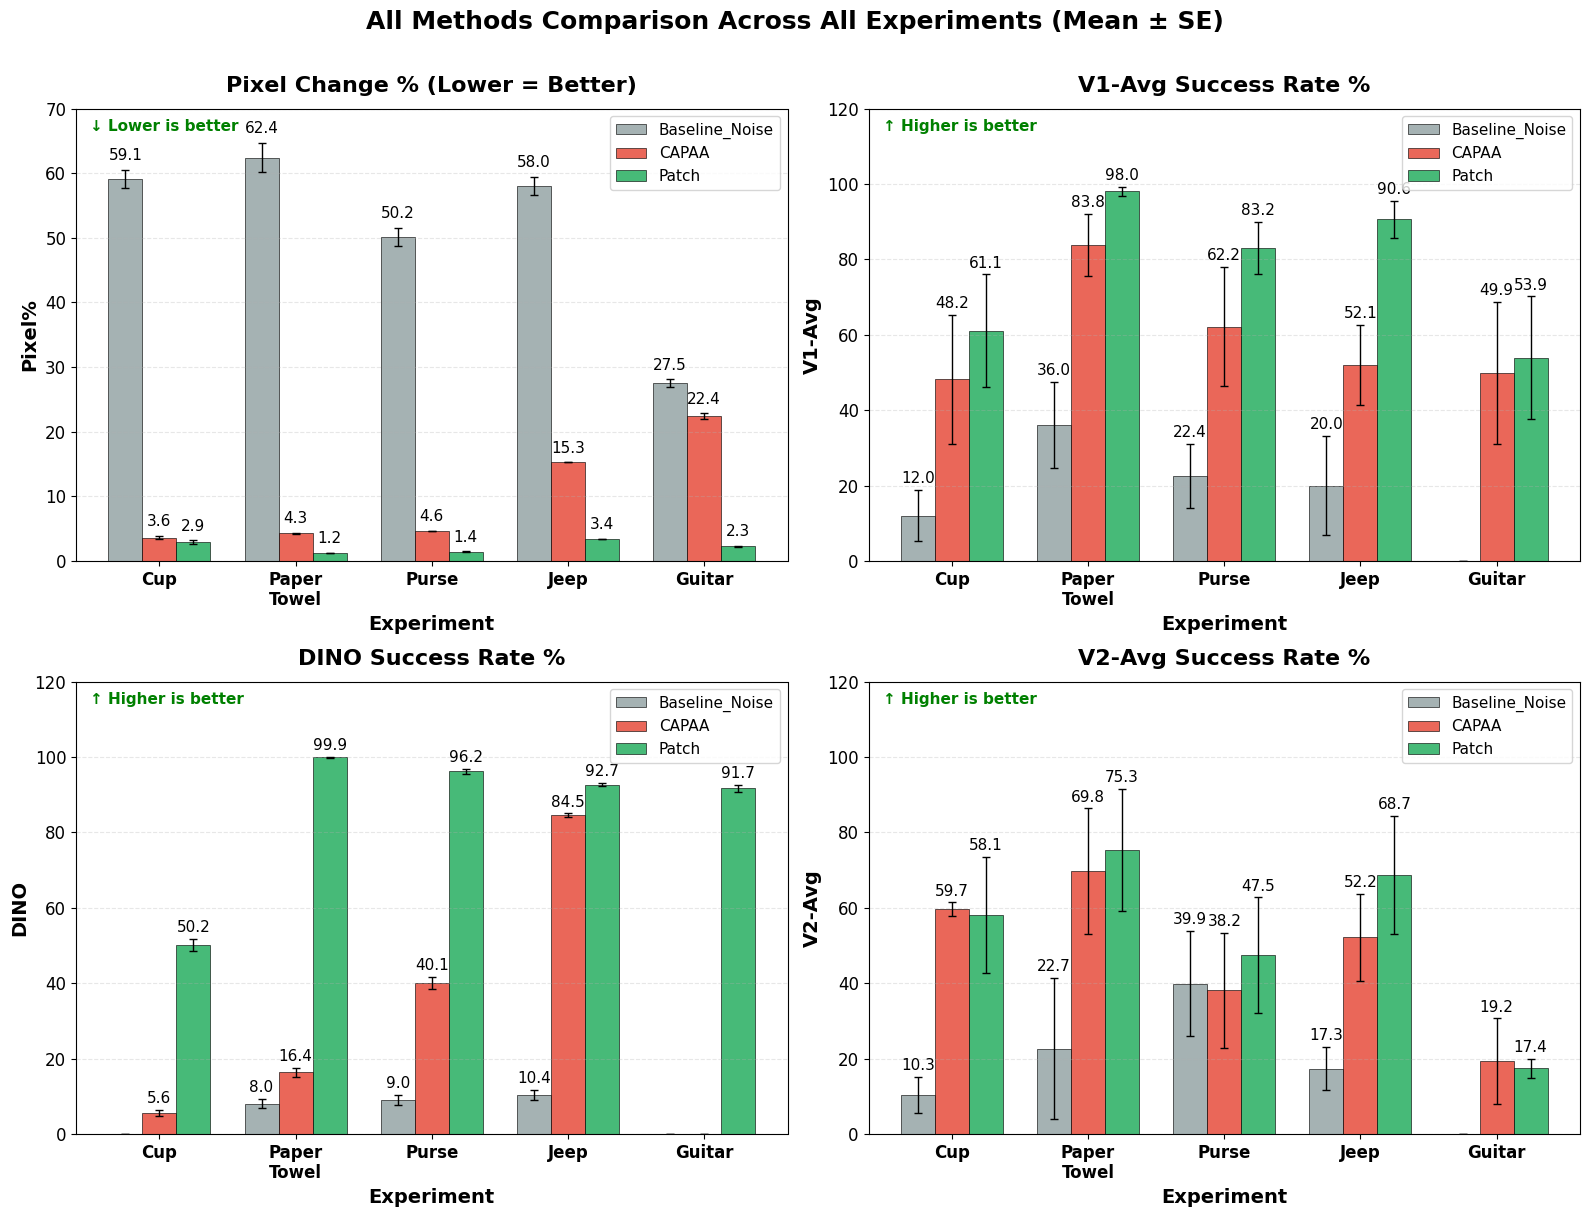


Chart saved to: C:\git\PhysicalAdverserialProj\total_experiments_analysis\all_methods_comparison.png
SVG saved to: C:\git\PhysicalAdverserialProj\total_experiments_analysis\paper_figures\all_methods_comparison.svg

COLORFUL SUMMARY TABLES: One Table Per Scenario


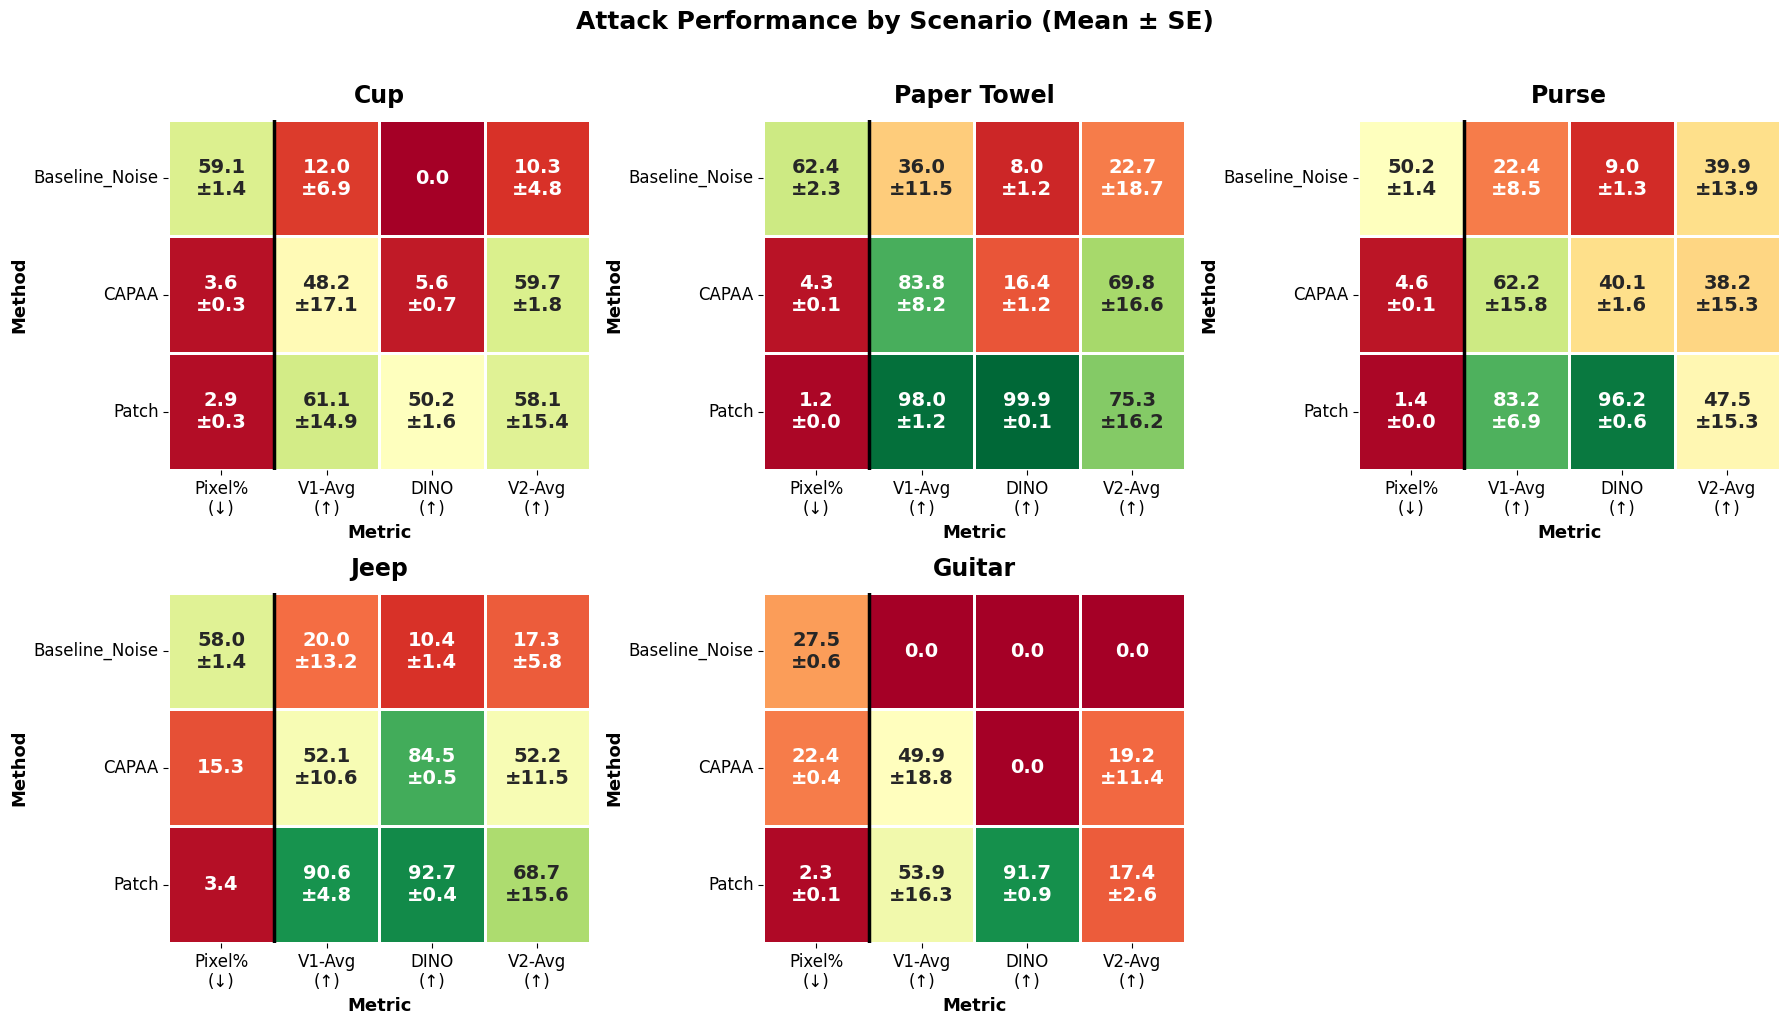


Scenario tables saved to: C:\git\PhysicalAdverserialProj\total_experiments_analysis\summary_by_scenario.png
SVG saved to: C:\git\PhysicalAdverserialProj\total_experiments_analysis\paper_figures\summary_by_scenario.svg

LATEX TABLE (Copy for paper)
\begin{table*}[h]
\caption{\textbf{Quantitative Comparisons. We compare attack success rates of to CAPAA \cite{CAPAA}} over 5 novel viewpoints and 20 captures per viewpoint. \textit{Seen} represents attacking classifiers used during optimization, DINO is optimization and attacking performed over a DINO classification head only, Unseen are 5 different classifiers not used during optimization, and Pixels refers to the percent of camera-space pixels used for the attack.}
\label{tab:untargeted}
\centering
\begin{tabular}{|c|c|c|c|c|c|c|c|c|c|c|c|c|}
\hline
 & \multicolumn{4}{|c|}{Jeep} & \multicolumn{4}{|c|}{Paper Towel} & \multicolumn{4}{|c|}{Cup} \\
\hline
 & Seen & DINO & Unseen & Pixels & Seen & DINO & Unseen & Pixels & Seen & DINO & Unseen 

In [8]:
# Create output directory for paper figures (SVG format)
PAPER_FIGURES_PATH = os.path.join(BASE_PATH, 'paper_figures')
os.makedirs(PAPER_FIGURES_PATH, exist_ok=True)
print(f"Paper figures will be saved to: {PAPER_FIGURES_PATH}")

# Grouped bar chart: All methods across all setups with confidence intervals
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

# Metrics to compare
metrics = ['Pixel%', 'V1-Avg', 'DINO', 'V2-Avg']
se_cols = ['Pixel_SE', 'V1-Avg_SE', 'DINO_SE', 'V2-Avg_SE']
metric_titles = ['Pixel Change % (Lower = Better)', 'V1-Avg Success Rate %', 'DINO Success Rate %', 'V2-Avg Success Rate %']
metric_colors = {
    'Baseline_Noise': '#95a5a6',  # Gray
    'CAPAA': '#e74c3c',           # Red
    'Patch': '#27ae60'            # Green
}

experiments_order = ['cup', 'paper_towel', 'purse', 'jeep', 'guitar']
methods_order = ['Baseline_Noise', 'CAPAA', 'Patch']

for idx, (metric, se_col, title) in enumerate(zip(metrics, se_cols, metric_titles)):
    ax = axes[idx]
    
    # Gather data and SE for this metric
    data_by_method = {m: [] for m in methods_order}
    se_by_method = {m: [] for m in methods_order}
    exp_labels = []
    
    for exp_name in experiments_order:
        if exp_name not in all_tables:
            continue
        table = all_tables[exp_name]
        exp_labels.append(exp_name.replace('_', '\n').title())
        
        for method in methods_order:
            method_row = table[table['Method'] == method]
            if len(method_row) > 0 and metric in method_row.columns:
                val = method_row[metric].values[0]
                se = method_row[se_col].values[0] if se_col in method_row.columns else 0
                data_by_method[method].append(val if not pd.isna(val) else 0)
                se_by_method[method].append(se if not pd.isna(se) else 0)
            else:
                data_by_method[method].append(0)
                se_by_method[method].append(0)
    
    # Plot grouped bars with error bars
    x = np.arange(len(exp_labels))
    width = 0.25
    
    for i, method in enumerate(methods_order):
        offset = (i - 1) * width
        bars = ax.bar(x + offset, data_by_method[method], width, 
                     label=method, color=metric_colors[method], alpha=0.85,
                     edgecolor='black', linewidth=0.5,
                     yerr=se_by_method[method], capsize=3, 
                     error_kw={'elinewidth': 1, 'capthick': 1})
        
        # Add value labels
        for j, bar in enumerate(bars):
            height = bar.get_height()
            se = se_by_method[method][j]
            if height > 0:
                ax.text(bar.get_x() + bar.get_width()/2, height + se + 1,
                       f'{height:.1f}', ha='center', va='bottom', fontsize=11, rotation=0)
    
    ax.set_xlabel('Experiment', fontweight='bold', fontsize=14)
    ax.set_ylabel(metric, fontweight='bold', fontsize=14)
    ax.set_title(title, fontsize=16, fontweight='bold', pad=12)
    ax.set_xticks(x)
    ax.set_xticklabels(exp_labels, fontsize=12, fontweight='bold')
    ax.tick_params(axis='y', labelsize=12)
    ax.legend(loc='upper right', fontsize=11)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Set y-axis limit
    if metric == 'Pixel%':
        ax.set_ylim(0, 70)
        # Add annotation for "lower is better"
        ax.annotate('↓ Lower is better', xy=(0.02, 0.95), xycoords='axes fraction',
                   fontsize=11, color='green', fontweight='bold')
    else:
        ax.set_ylim(0, 120)
        # Add annotation for "higher is better"
        ax.annotate('↑ Higher is better', xy=(0.02, 0.95), xycoords='axes fraction',
                   fontsize=11, color='green', fontweight='bold')

plt.suptitle('All Methods Comparison Across All Experiments (Mean ± SE)', fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
# Save as both PNG and SVG
plt.savefig(os.path.join(BASE_PATH, 'all_methods_comparison.png'), dpi=150, bbox_inches='tight')
plt.savefig(os.path.join(PAPER_FIGURES_PATH, 'all_methods_comparison.svg'), format='svg', bbox_inches='tight')
plt.show()

print(f"\nChart saved to: {os.path.join(BASE_PATH, 'all_methods_comparison.png')}")
print(f"SVG saved to: {os.path.join(PAPER_FIGURES_PATH, 'all_methods_comparison.svg')}")

# Create 2x3 grid of heatmaps - one per SCENARIO (experiment)
# Each table: rows=methods, columns=metrics (Pixel%, V1-Avg, DINO, V2-Avg)
print("\n" + "="*100)
print("COLORFUL SUMMARY TABLES: One Table Per Scenario")
print("="*100)

summary_metrics = ['Pixel%', 'V1-Avg', 'DINO', 'V2-Avg']
summary_se_cols = ['Pixel_SE', 'V1-Avg_SE', 'DINO_SE', 'V2-Avg_SE']
metric_col_labels = ['Pixel%\n(↓)', 'V1-Avg\n(↑)', 'DINO\n(↑)', 'V2-Avg\n(↑)']
method_labels = ['Baseline_Noise', 'CAPAA', 'Patch']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

exp_titles = {'cup': 'Cup', 'paper_towel': 'Paper Towel', 'purse': 'Purse', 'jeep': 'Jeep', 'guitar': 'Guitar'}

for idx, exp_name in enumerate(experiments_order):
    ax = axes[idx]
    
    if exp_name not in all_tables:
        ax.axis('off')
        continue
    
    table = all_tables[exp_name]
    
    # Build data matrix: rows=methods, columns=metrics
    data_matrix = []
    annot_matrix = []
    
    for method in method_labels:
        method_row = table[table['Method'] == method]
        row_vals = []
        row_annot = []
        
        for metric, se_col in zip(summary_metrics, summary_se_cols):
            if len(method_row) == 0:
                row_vals.append(np.nan)
                row_annot.append('--')
            else:
                val = method_row[metric].values[0]
                se = method_row[se_col].values[0] if se_col in method_row.columns else np.nan
                
                if pd.isna(val):
                    row_vals.append(np.nan)
                    row_annot.append('--')
                else:
                    row_vals.append(val)
                    if pd.isna(se) or se == 0:
                        row_annot.append(f'{val:.1f}')
                    else:
                        row_annot.append(f'{val:.1f}\n±{se:.1f}')
        
        data_matrix.append(row_vals)
        annot_matrix.append(row_annot)
    
    # Create DataFrame
    df_exp = pd.DataFrame(data_matrix, columns=metric_col_labels, index=method_labels)
    annot_array = np.array(annot_matrix)
    
    # Plot heatmap with RdYlGn colormap (higher=green is good for success rates)
    sns.heatmap(df_exp, annot=annot_array, fmt='', cmap='RdYlGn', 
                center=50, vmin=0, vmax=100,
                linewidths=2, linecolor='white',
                cbar=False,
                annot_kws={'size': 14, 'weight': 'bold'},
                ax=ax)
    
    # Title with experiment name (INCREASED FONT SIZE)
    ax.set_title(f'{exp_titles[exp_name]}', fontsize=17, fontweight='bold', pad=12)
    ax.set_xlabel('Metric', fontsize=13, fontweight='bold')
    ax.set_ylabel('Method', fontsize=13, fontweight='bold')
    
    ax.tick_params(axis='x', rotation=0, labelsize=12)
    ax.tick_params(axis='y', rotation=0, labelsize=12)
    
    # Add vertical line after Pixel% to separate it (since lower is better for Pixel%)
    ax.axvline(x=1, color='black', linewidth=2.5)

# Hide any unused subplots (e.g., 6th subplot in 2x3 grid with 5 experiments)
for idx in range(len(experiments_order), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Attack Performance by Scenario (Mean ± SE)', 
             fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(BASE_PATH, 'summary_by_scenario.png'), dpi=150, bbox_inches='tight')
plt.savefig(os.path.join(PAPER_FIGURES_PATH, 'summary_by_scenario.svg'), format='svg', bbox_inches='tight')
plt.show()

print(f"\nScenario tables saved to: {os.path.join(BASE_PATH, 'summary_by_scenario.png')}")
print(f"SVG saved to: {os.path.join(PAPER_FIGURES_PATH, 'summary_by_scenario.svg')}")

# Generate LaTeX table in the requested format
print("\n" + "="*100)
print("LATEX TABLE (Copy for paper)")
print("="*100)

# Mapping: Baseline_Noise -> Baseline, CAPAA -> CAPAA, Patch -> Ours
method_mapping = {'Baseline_Noise': 'Baseline', 'CAPAA': 'CAPAA', 'Patch': 'Ours'}
# Experiments order for the table: Jeep, Paper Towel, Cup in first row; Guitar, Purse, Total in second row
table_experiments = ['jeep', 'paper_towel', 'cup', 'purse', 'guitar']

def get_latex_val(exp_name, method, metric, se_col):
    """Get formatted value ± SE for LaTeX"""
    if exp_name not in all_tables:
        return ''
    table = all_tables[exp_name]
    method_row = table[table['Method'] == method]
    if len(method_row) == 0:
        return ''
    val = method_row[metric].values[0]
    se = method_row[se_col].values[0] if se_col in method_row.columns else np.nan
    if pd.isna(val):
        return ''
    if pd.isna(se) or se == 0:
        return f'{val:.1f}'
    return f'{val:.1f} $\\pm$ {se:.1f}'

# Calculate totals (average across all experiments)
total_data = {}
for method in ['Baseline_Noise', 'CAPAA', 'Patch']:
    total_data[method] = {}
    for metric, se_col in [('V1-Avg', 'V1-Avg_SE'), ('DINO', 'DINO_SE'), ('V2-Avg', 'V2-Avg_SE'), ('Pixel%', 'Pixel_SE')]:
        vals = []
        ses = []
        for exp_name in table_experiments:
            if exp_name not in all_tables:
                continue
            table = all_tables[exp_name]
            method_row = table[table['Method'] == method]
            if len(method_row) > 0:
                v = method_row[metric].values[0]
                s = method_row[se_col].values[0] if se_col in method_row.columns else np.nan
                if not pd.isna(v):
                    vals.append(v)
                    if not pd.isna(s):
                        ses.append(s)
        if vals:
            mean_val = np.mean(vals)
            # Propagate SE: sqrt(sum(se^2))/n
            mean_se = np.sqrt(np.sum([s**2 for s in ses])) / len(vals) if ses else 0
            if mean_se > 0:
                total_data[method][metric] = f'{mean_val:.1f} $\\pm$ {mean_se:.1f}'
            else:
                total_data[method][metric] = f'{mean_val:.1f}'
        else:
            total_data[method][metric] = ''

# Build LaTeX table
latex_table = r"""\begin{table*}[h]
\caption{\textbf{Quantitative Comparisons. We compare attack success rates of to CAPAA \cite{CAPAA}} over 5 novel viewpoints and 20 captures per viewpoint. \textit{Seen} represents attacking classifiers used during optimization, DINO is optimization and attacking performed over a DINO classification head only, Unseen are 5 different classifiers not used during optimization, and Pixels refers to the percent of camera-space pixels used for the attack.}
\label{tab:untargeted}
\centering
\begin{tabular}{|c|c|c|c|c|c|c|c|c|c|c|c|c|}
\hline
 & \multicolumn{4}{|c|}{Jeep} & \multicolumn{4}{|c|}{Paper Towel} & \multicolumn{4}{|c|}{Cup} \\
\hline
 & Seen & DINO & Unseen & Pixels & Seen & DINO & Unseen & Pixels & Seen & DINO & Unseen & Pixels \\
\hline
"""

# Row 1: Jeep, Paper Towel, Cup
for method, label in [('Baseline_Noise', 'Baseline'), ('CAPAA', 'CAPAA'), ('Patch', 'Ours')]:
    row = f"{label}"
    for exp_name in ['jeep', 'paper_towel', 'cup']:
        seen = get_latex_val(exp_name, method, 'V1-Avg', 'V1-Avg_SE')
        dino = get_latex_val(exp_name, method, 'DINO', 'DINO_SE')
        unseen = get_latex_val(exp_name, method, 'V2-Avg', 'V2-Avg_SE')
        pixels = get_latex_val(exp_name, method, 'Pixel%', 'Pixel_SE')
        row += f"&{seen}&{dino}&{unseen}&{pixels}"
    row += r" \\" + "\n\\hline\n"
    latex_table += row

# Second part of table
latex_table += r""" & \multicolumn{4}{|c|}{Guitar} & \multicolumn{4}{|c|}{Purse} & \multicolumn{4}{|c|}{Total} \\
\hline
 & Seen & DINO & Unseen & Pixels & Seen & DINO & Unseen & Pixels & Seen & DINO & Unseen & Pixels \\
\hline
"""

# Row 2: Guitar, Purse, Total
for method, label in [('Baseline_Noise', 'Baseline'), ('CAPAA', 'CAPAA'), ('Patch', 'Ours')]:
    row = f"{label}"
    # Guitar
    seen = get_latex_val('guitar', method, 'V1-Avg', 'V1-Avg_SE')
    dino = get_latex_val('guitar', method, 'DINO', 'DINO_SE')
    unseen = get_latex_val('guitar', method, 'V2-Avg', 'V2-Avg_SE')
    pixels = get_latex_val('guitar', method, 'Pixel%', 'Pixel_SE')
    row += f"&{seen}&{dino}&{unseen}&{pixels}"
    # Purse
    seen = get_latex_val('purse', method, 'V1-Avg', 'V1-Avg_SE')
    dino = get_latex_val('purse', method, 'DINO', 'DINO_SE')
    unseen = get_latex_val('purse', method, 'V2-Avg', 'V2-Avg_SE')
    pixels = get_latex_val('purse', method, 'Pixel%', 'Pixel_SE')
    row += f"&{seen}&{dino}&{unseen}&{pixels}"
    # Total
    row += f"&{total_data[method].get('V1-Avg', '')}&{total_data[method].get('DINO', '')}&{total_data[method].get('V2-Avg', '')}&{total_data[method].get('Pixel%', '')}"
    row += r" \\" + "\n\\hline\n"
    latex_table += row

latex_table += r"""\end{tabular}
\end{table*}"""

print(latex_table)

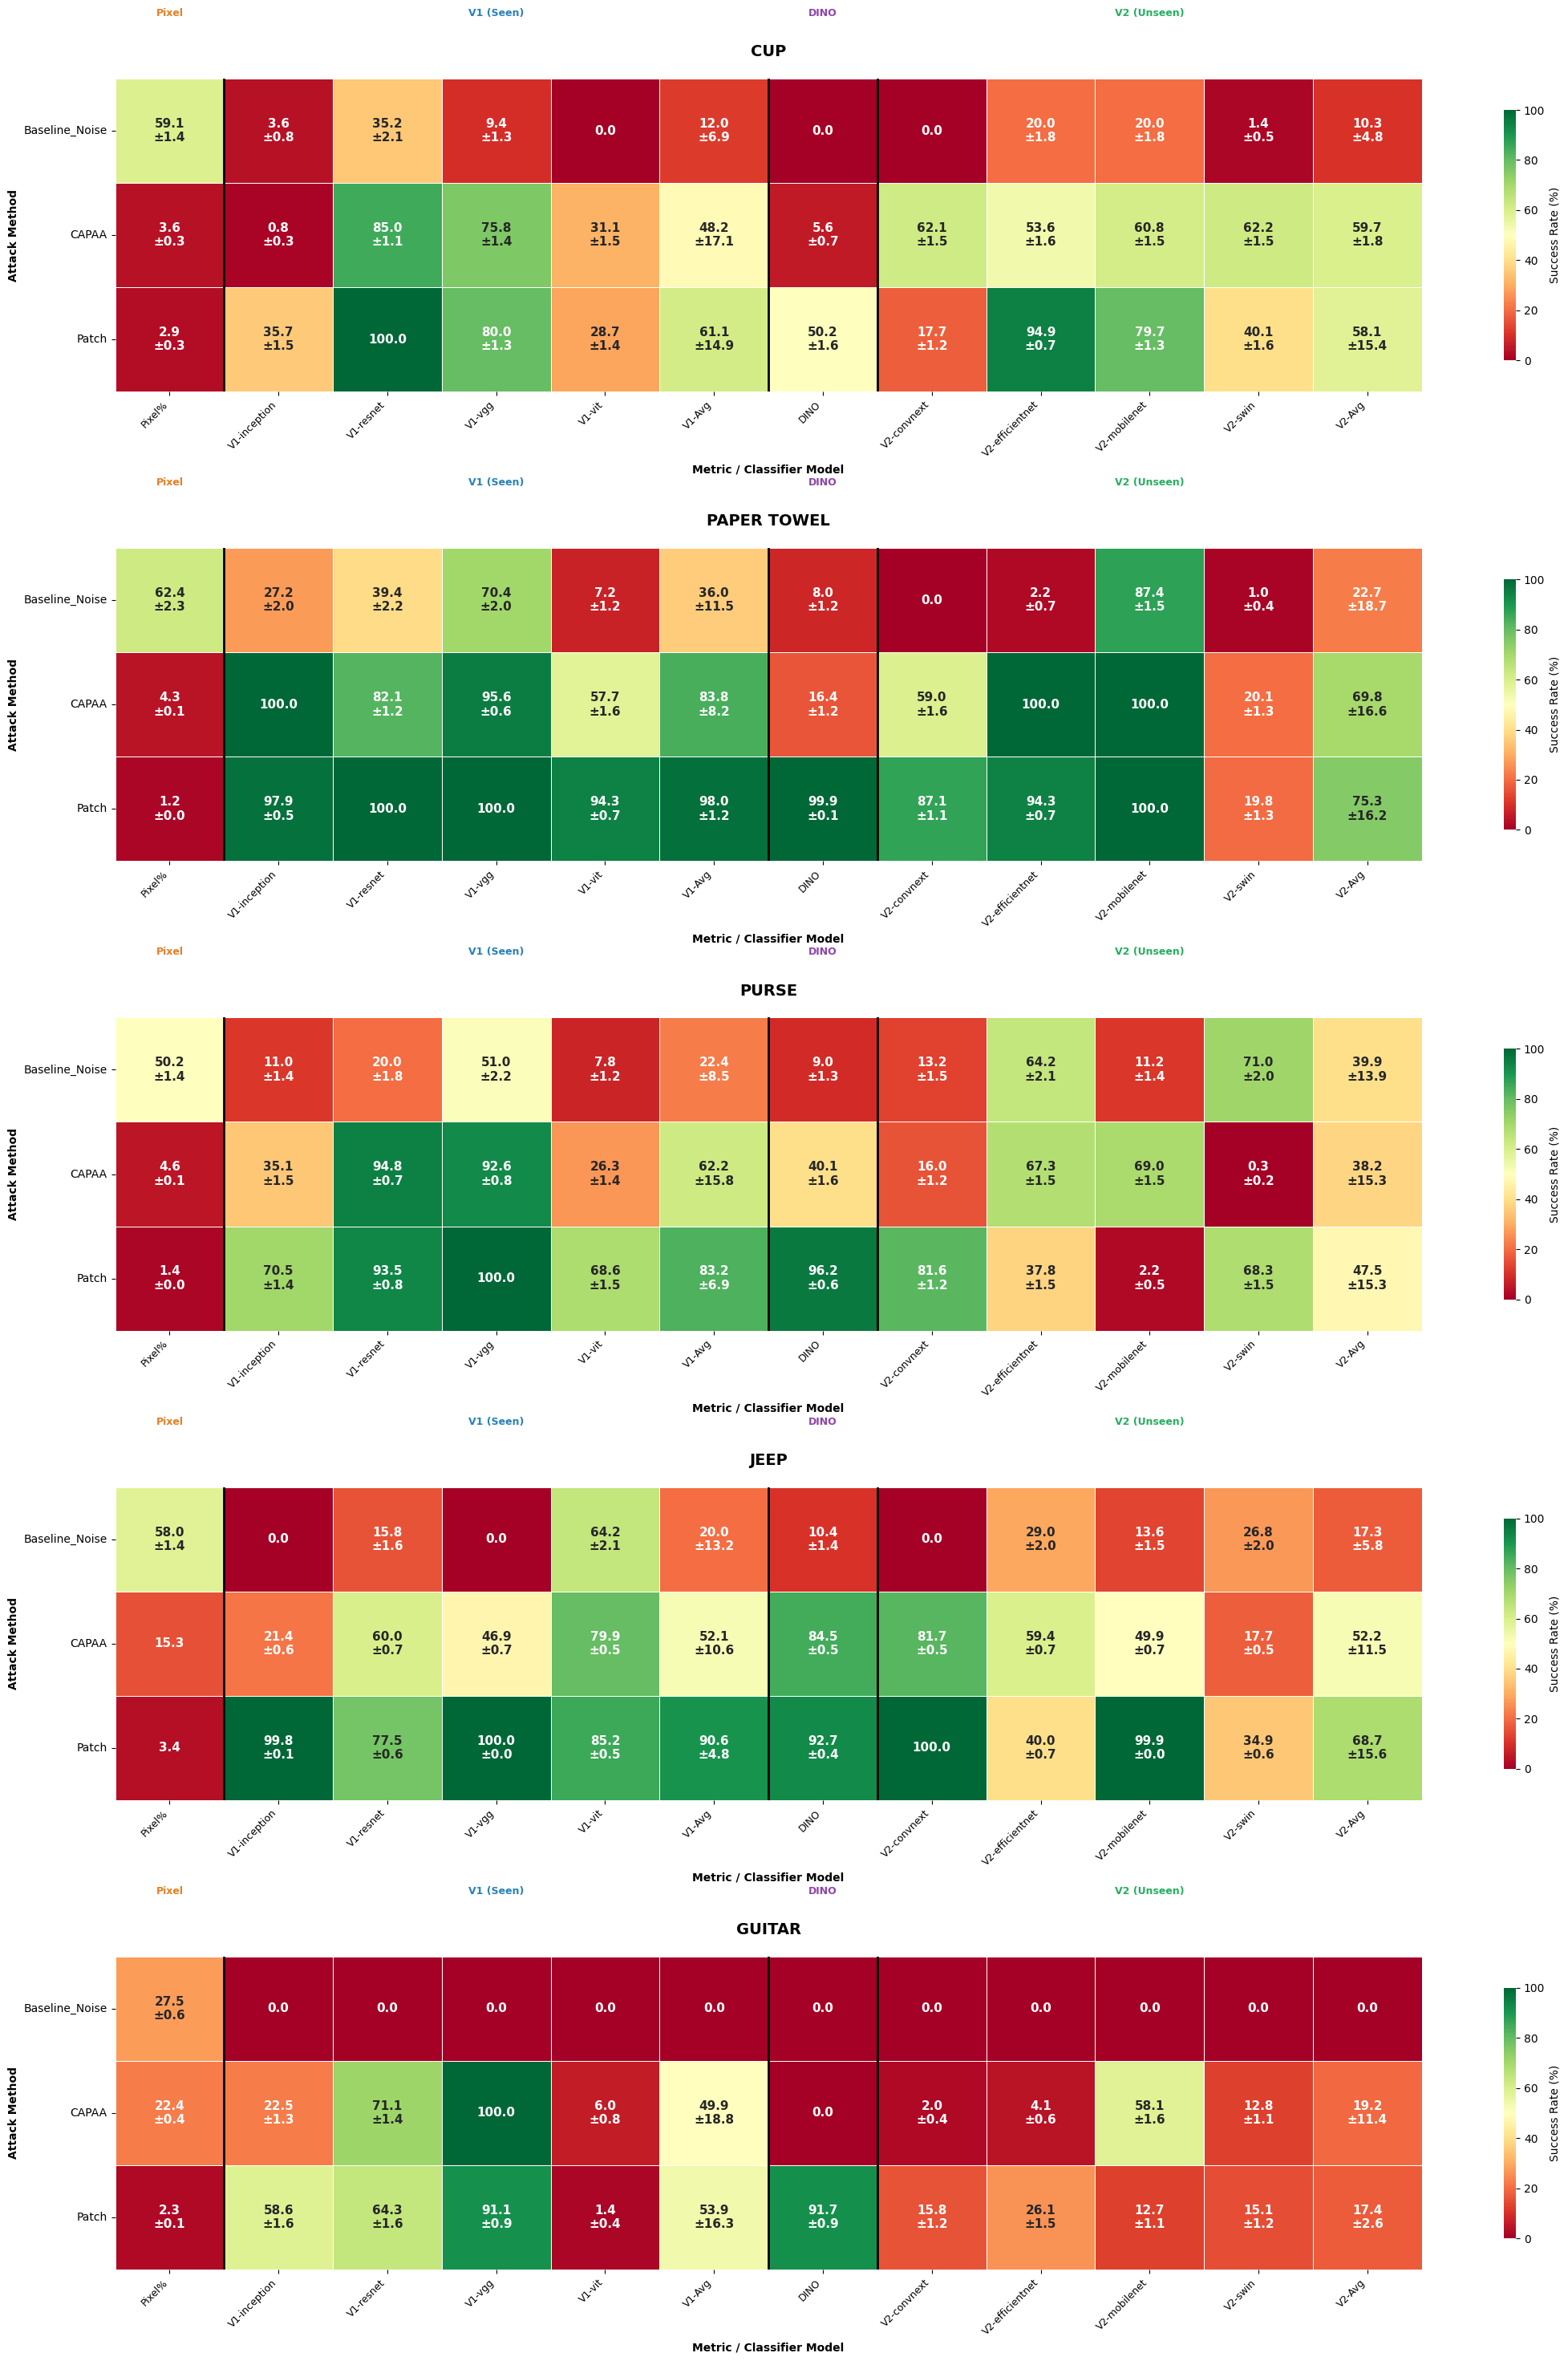


Heatmap saved to: C:\git\PhysicalAdverserialProj\total_experiments_analysis\heatmaps_with_ci.png


In [9]:
# Create heatmaps for each experiment with confidence intervals
n_experiments = len(all_tables)
fig, axes = plt.subplots(n_experiments, 1, figsize=(22, 6 * n_experiments))
if n_experiments == 1:
    axes = [axes]

for idx, (exp_name, table) in enumerate(all_tables.items()):
    ax = axes[idx]
    
    # Get value columns (without SE) for display
    value_cols = ['Pixel%', 'V1-inception', 'V1-resnet', 'V1-vgg', 'V1-vit', 'V1-Avg',
                  'DINO', 'V2-convnext', 'V2-efficientnet', 'V2-mobilenet', 'V2-swin', 'V2-Avg']
    value_cols = [c for c in value_cols if c in table.columns]
    
    # Create heatmap data (just values)
    heatmap_data = table.set_index('Method')[value_cols]
    heatmap_display = heatmap_data.fillna(-1)
    
    # Create annotation strings with ± SE
    annot_data = []
    for _, row in table.iterrows():
        row_annot = []
        for col in value_cols:
            val = row[col]
            se_col = col + '_SE' if col != 'Pixel%' else 'Pixel_SE'
            se = row.get(se_col, np.nan) if se_col in row else np.nan
            if pd.isna(val):
                row_annot.append('')
            elif pd.isna(se) or se == 0:
                row_annot.append(f'{val:.1f}')
            else:
                row_annot.append(f'{val:.1f}\n±{se:.1f}')
        annot_data.append(row_annot)
    
    annot_array = np.array(annot_data)
    
    sns.heatmap(heatmap_display, annot=annot_array, fmt='', cmap='RdYlGn', 
                center=50, vmin=0, vmax=100,
                linewidths=0.5, linecolor='white',
                cbar_kws={'label': 'Success Rate (%)', 'shrink': 0.8},
                annot_kws={'size': 11, 'weight': 'bold'},
                mask=(heatmap_display == -1),
                ax=ax)
    
    ax.set_title(f"{exp_name.upper().replace('_', ' ')}", 
                 fontsize=14, fontweight='bold', pad=20)
    ax.set_xlabel('Metric / Classifier Model', fontsize=10, fontweight='bold')
    ax.set_ylabel('Attack Method', fontsize=10, fontweight='bold')
    
    plt.sca(ax)
    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.yticks(rotation=0, fontsize=10)
    
    # Add vertical lines to separate groups (adjusted for new columns)
    # Pixel% | V1 models (4) + V1-Avg | DINO | V2 models (4) + V2-Avg
    ax.axvline(x=1, color='black', linewidth=2)   # After Pixel%
    ax.axvline(x=6, color='black', linewidth=2)   # After V1-Avg
    ax.axvline(x=7, color='black', linewidth=2)   # After DINO
    
    # Add group labels at the top
    ax.text(0.5, -0.6, 'Pixel', ha='center', fontsize=9, fontweight='bold', color='#e67e22')
    ax.text(3.5, -0.6, 'V1 (Seen)', ha='center', fontsize=9, fontweight='bold', color='#2980b9')
    ax.text(6.5, -0.6, 'DINO', ha='center', fontsize=9, fontweight='bold', color='#8e44ad')
    ax.text(9.5, -0.6, 'V2 (Unseen)', ha='center', fontsize=9, fontweight='bold', color='#27ae60')

plt.tight_layout()
plt.subplots_adjust(hspace=0.5, top=0.95)
plt.savefig(os.path.join(BASE_PATH, 'heatmaps_with_ci.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\nHeatmap saved to: {os.path.join(BASE_PATH, 'heatmaps_with_ci.png')}")

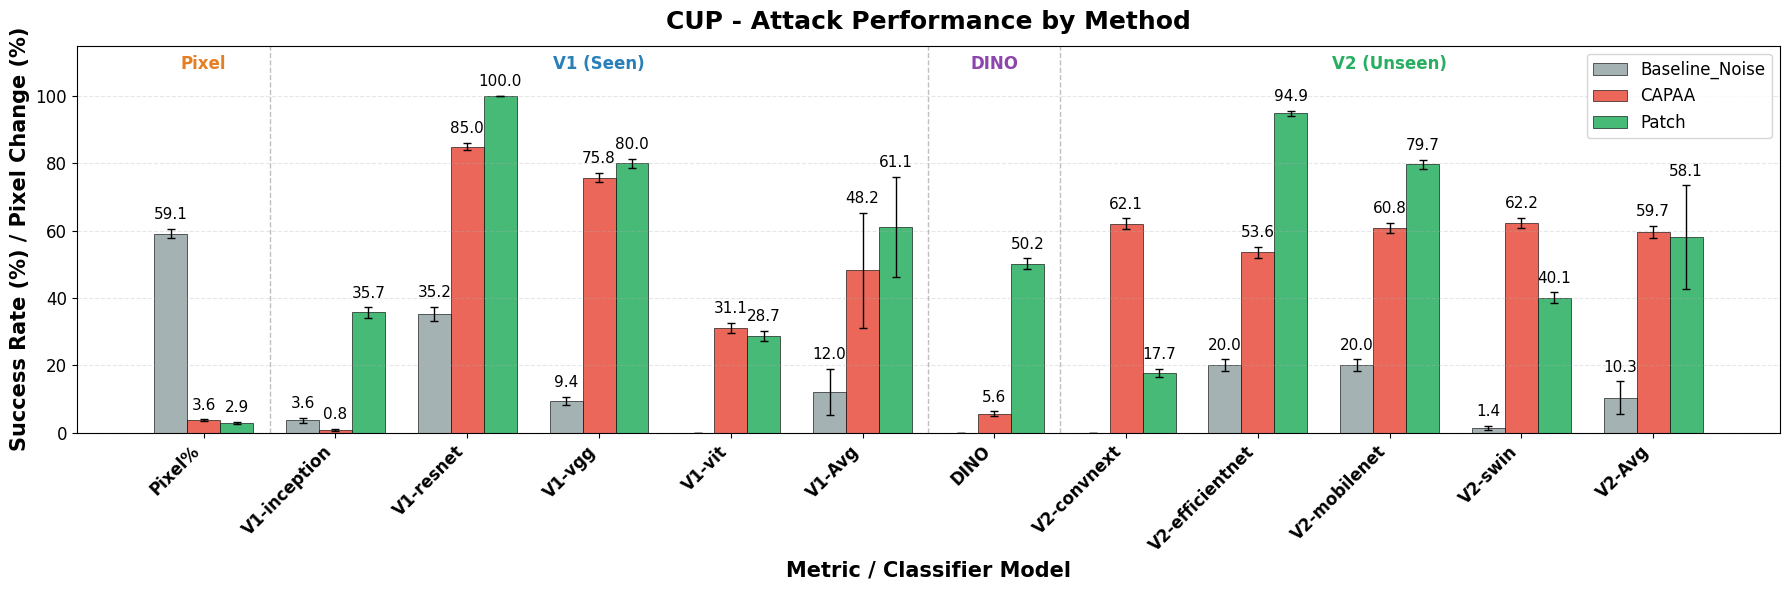

Bar plot saved to: C:\git\PhysicalAdverserialProj\total_experiments_analysis\bar_plot_cup.png
SVG saved to: C:\git\PhysicalAdverserialProj\total_experiments_analysis\paper_figures\bar_plot_cup.svg



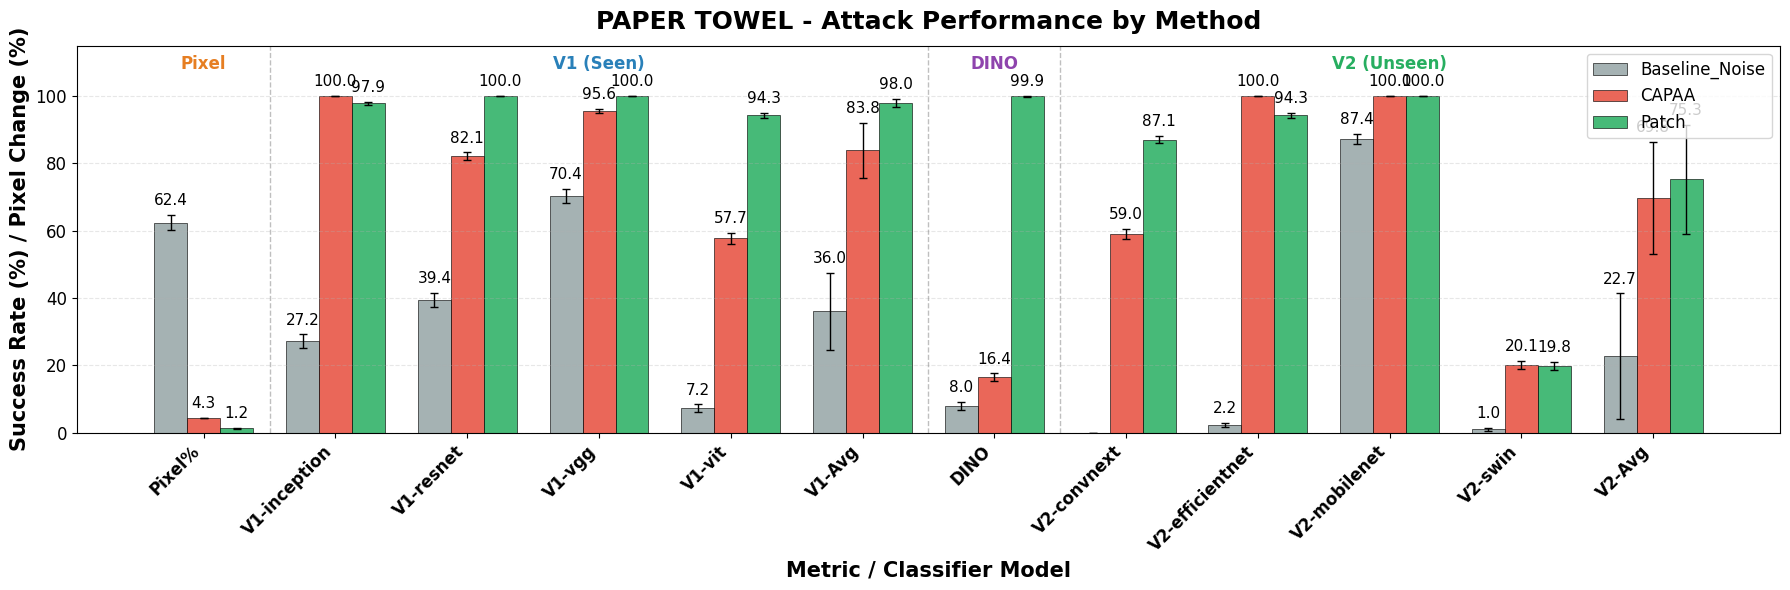

Bar plot saved to: C:\git\PhysicalAdverserialProj\total_experiments_analysis\bar_plot_paper_towel.png
SVG saved to: C:\git\PhysicalAdverserialProj\total_experiments_analysis\paper_figures\bar_plot_paper_towel.svg



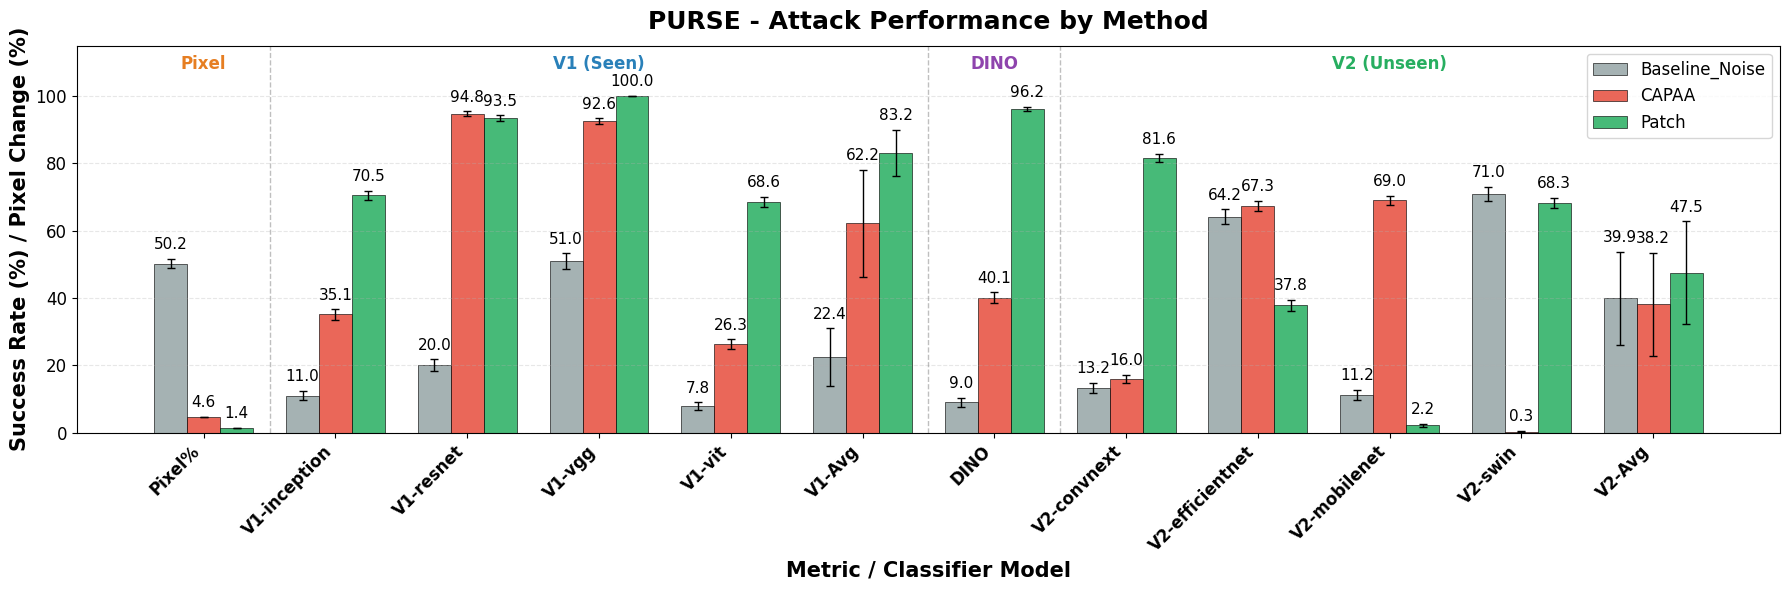

Bar plot saved to: C:\git\PhysicalAdverserialProj\total_experiments_analysis\bar_plot_purse.png
SVG saved to: C:\git\PhysicalAdverserialProj\total_experiments_analysis\paper_figures\bar_plot_purse.svg



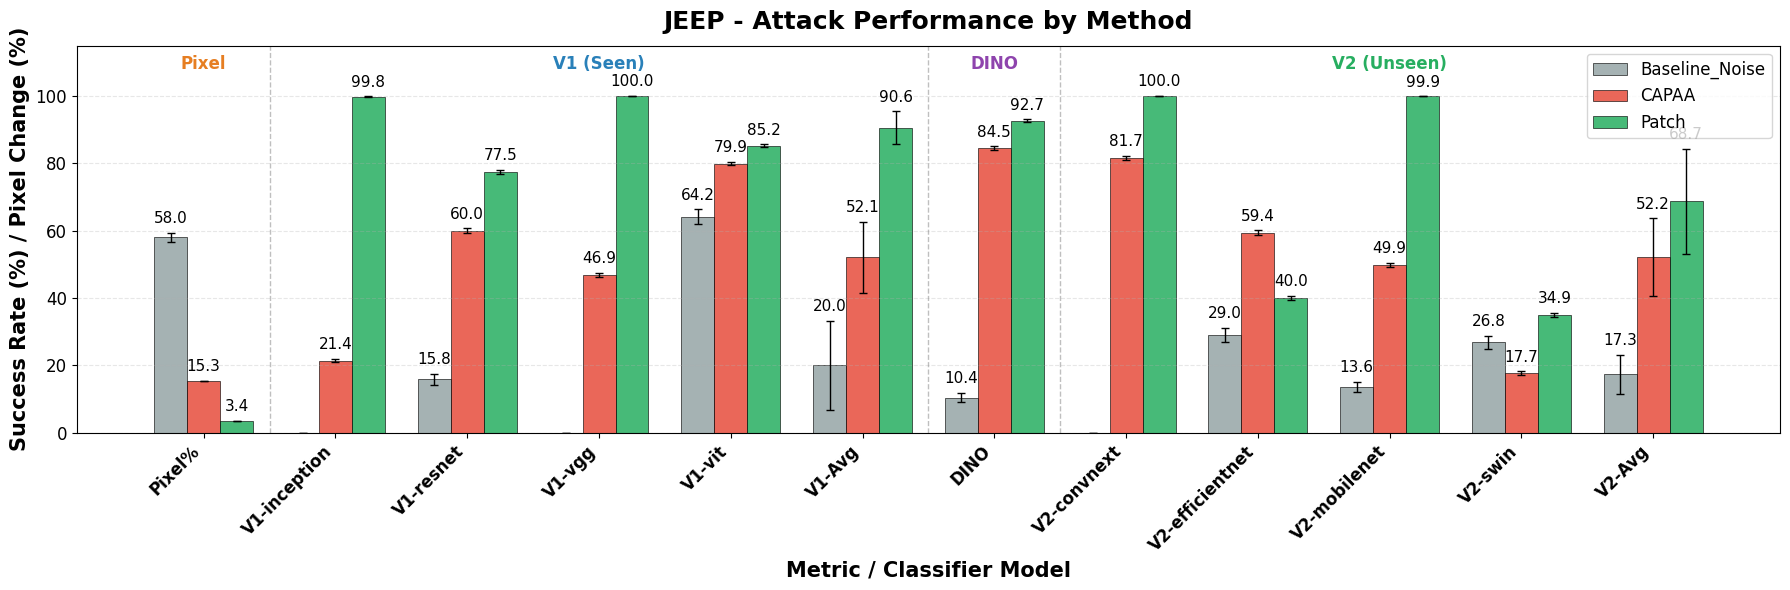

Bar plot saved to: C:\git\PhysicalAdverserialProj\total_experiments_analysis\bar_plot_jeep.png
SVG saved to: C:\git\PhysicalAdverserialProj\total_experiments_analysis\paper_figures\bar_plot_jeep.svg



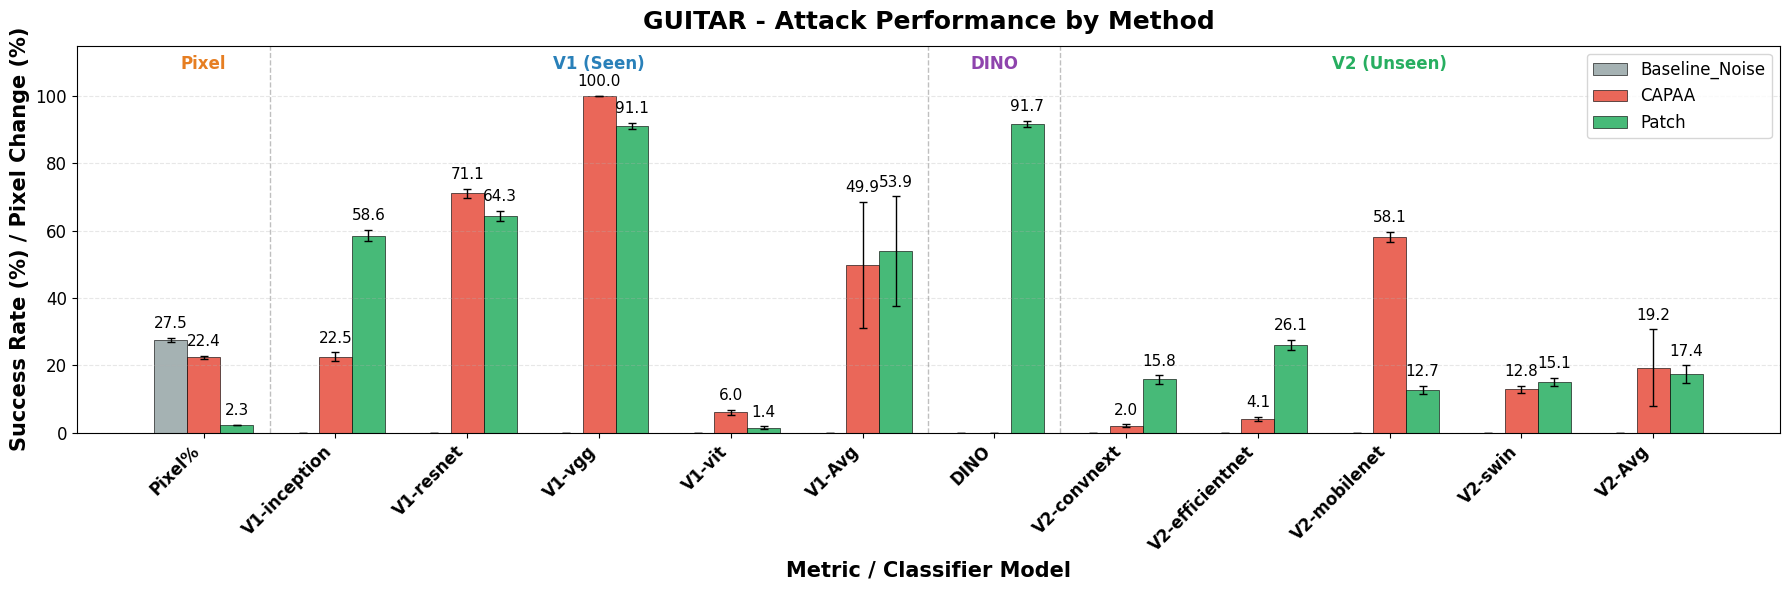

Bar plot saved to: C:\git\PhysicalAdverserialProj\total_experiments_analysis\bar_plot_guitar.png
SVG saved to: C:\git\PhysicalAdverserialProj\total_experiments_analysis\paper_figures\bar_plot_guitar.svg



In [10]:
# Bar plots for each scenario - showing all metrics per method (PAPER VERSION with larger fonts)
method_colors = {
    'Baseline_Noise': '#95a5a6',  # Gray
    'CAPAA': '#e74c3c',           # Red
    'Patch': '#27ae60'            # Green
}

# Create a separate bar plot for each experiment
for exp_name, table in all_tables.items():
    # Get metrics
    metrics = ['Pixel%', 'V1-inception', 'V1-resnet', 'V1-vgg', 'V1-vit', 'V1-Avg',
               'DINO', 'V2-convnext', 'V2-efficientnet', 'V2-mobilenet', 'V2-swin', 'V2-Avg']
    metrics = [m for m in metrics if m in table.columns]
    
    methods = table['Method'].tolist()
    n_methods = len(methods)
    n_metrics = len(metrics)
    
    fig, ax = plt.subplots(figsize=(18, 6))
    
    x = np.arange(n_metrics)
    width = 0.25
    
    for i, method in enumerate(methods):
        row = table[table['Method'] == method].iloc[0]
        values = []
        errors = []
        
        for metric in metrics:
            val = row.get(metric, np.nan)
            se_col = metric + '_SE' if metric != 'Pixel%' else 'Pixel_SE'
            se = row.get(se_col, 0) if se_col in row else 0
            
            values.append(val if not pd.isna(val) else 0)
            errors.append(se if not pd.isna(se) else 0)
        
        offset = (i - (n_methods - 1) / 2) * width
        bars = ax.bar(x + offset, values, width, 
                     label=method, color=method_colors.get(method, '#3498db'), 
                     alpha=0.85, edgecolor='black', linewidth=0.5,
                     yerr=errors, capsize=3, error_kw={'elinewidth': 1, 'capthick': 1})
        
        # Add value labels on top of bars
        for j, bar in enumerate(bars):
            height = bar.get_height()
            if height > 0:
                ax.text(bar.get_x() + bar.get_width()/2, height + errors[j] + 2,
                       f'{height:.1f}', ha='center', va='bottom', fontsize=11, rotation=0)
    
    ax.set_xlabel('Metric / Classifier Model', fontweight='bold', fontsize=15)
    ax.set_ylabel('Success Rate (%) / Pixel Change (%)', fontweight='bold', fontsize=15)
    ax.set_title(f"{exp_name.upper().replace('_', ' ')} - Attack Performance by Method", 
                 fontsize=18, fontweight='bold', pad=12)
    ax.set_xticks(x)
    ax.set_xticklabels(metrics, rotation=45, ha='right', fontsize=12, fontweight='bold')
    ax.tick_params(axis='y', labelsize=12)
    ax.legend(loc='upper right', fontsize=12)
    ax.set_ylim(0, 115)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Add vertical separators for groups
    ax.axvline(x=0.5, color='gray', linewidth=1, linestyle='--', alpha=0.5)  # After Pixel%
    ax.axvline(x=5.5, color='gray', linewidth=1, linestyle='--', alpha=0.5)  # After V1-Avg
    ax.axvline(x=6.5, color='gray', linewidth=1, linestyle='--', alpha=0.5)  # After DINO
    
    # Add group labels (INCREASED FONT SIZE)
    ax.text(0, 108, 'Pixel', ha='center', fontsize=12, fontweight='bold', color='#e67e22')
    ax.text(3, 108, 'V1 (Seen)', ha='center', fontsize=12, fontweight='bold', color='#2980b9')
    ax.text(6, 108, 'DINO', ha='center', fontsize=12, fontweight='bold', color='#8e44ad')
    ax.text(9, 108, 'V2 (Unseen)', ha='center', fontsize=12, fontweight='bold', color='#27ae60')
    
    plt.tight_layout()
    # Save as both PNG and SVG
    plt.savefig(os.path.join(BASE_PATH, f'bar_plot_{exp_name}.png'), dpi=150, bbox_inches='tight')
    plt.savefig(os.path.join(PAPER_FIGURES_PATH, f'bar_plot_{exp_name}.svg'), format='svg', bbox_inches='tight')
    plt.show()
    
    print(f"Bar plot saved to: {os.path.join(BASE_PATH, f'bar_plot_{exp_name}.png')}")
    print(f"SVG saved to: {os.path.join(PAPER_FIGURES_PATH, f'bar_plot_{exp_name}.svg')}\n")

In [11]:
# Summary comparison across all experiments
print("="*100)
print("SUMMARY COMPARISON ACROSS ALL EXPERIMENTS")
print("="*100)

summary_rows = []
for exp_name, table in all_tables.items():
    for _, row in table.iterrows():
        method = row['Method']
        pixel_pct = row.get('Pixel%', np.nan)
        v1_avg = row.get('V1-Avg', np.nan)
        dino = row.get('DINO', np.nan)
        v2_avg = row.get('V2-Avg', np.nan)
        
        # Calculate overall (excluding NaN)
        vals = [v for v in [v1_avg, dino, v2_avg] if not pd.isna(v)]
        overall = np.mean(vals) if vals else np.nan
        
        summary_rows.append({
            'Experiment': exp_name,
            'Method': method,
            'Pixel%': pixel_pct,
            'V1-Avg': v1_avg,
            'DINO': dino,
            'V2-Avg': v2_avg,
            'Overall': overall
        })

summary_df = pd.DataFrame(summary_rows)

# Pivot for better view
for metric in ['Pixel%', 'V1-Avg', 'DINO', 'V2-Avg', 'Overall']:
    print(f"\n--- {metric} ---")
    pivot = summary_df.pivot(index='Method', columns='Experiment', values=metric)
    pivot = pivot[['cup', 'paper_towel', 'purse', 'jeep', 'guitar']]  # Order columns
    print(pivot.round(1).to_string())

SUMMARY COMPARISON ACROSS ALL EXPERIMENTS

--- Pixel% ---
Experiment       cup  paper_towel  purse  jeep  guitar
Method                                                
Baseline_Noise  59.1         62.4   50.2  58.0    27.5
CAPAA            3.6          4.3    4.6  15.3    22.4
Patch            2.9          1.2    1.4   3.4     2.3

--- V1-Avg ---
Experiment       cup  paper_towel  purse  jeep  guitar
Method                                                
Baseline_Noise  12.0         36.0   22.4  20.0     0.0
CAPAA           48.2         83.8   62.2  52.1    49.9
Patch           61.1         98.0   83.2  90.6    53.9

--- DINO ---
Experiment       cup  paper_towel  purse  jeep  guitar
Method                                                
Baseline_Noise   0.0          8.0    9.0  10.4     0.0
CAPAA            5.6         16.4   40.1  84.5     0.0
Patch           50.2         99.9   96.2  92.7    91.7

--- V2-Avg ---
Experiment       cup  paper_towel  purse  jeep  guitar
Method          

In [12]:
summary_df

,Experiment,Method,Pixel%,V1-Avg,DINO,V2-Avg,Overall
0,cup,Baseline_Noise,59.104072,12.050000,0.000000,10.350000,7.466667
1,cup,CAPAA,3.606174,48.175000,5.600000,59.675000,37.816667
2,cup,Patch,2.905333,61.100000,50.200000,58.100000,56.466667
3,paper_towel,Baseline_Noise,62.434197,36.050000,8.000000,22.650000,22.233333
4,paper_towel,CAPAA,4.268338,83.850000,16.400000,69.775000,56.675000
5,paper_towel,Patch,1.243845,98.050000,99.900000,75.300000,91.083333
6,purse,Baseline_Noise,50.167211,22.450000,9.000000,39.900000,23.783333
7,purse,CAPAA,4.630480,62.200000,40.100000,38.150000,46.816667
8,purse,Patch,1.435371,83.150000,96.200000,47.475000,75.608333
9,jeep,Baseline_Noise,58.021886,20.000000,10.400000,17.350000,15.916667


In [13]:
# Final summary: CAPAA vs Patch comparison
print("="*100)
print("CAPAA vs PATCH - HEAD-TO-HEAD COMPARISON")
print("="*100)

comparison_data = []
for exp_name, table in all_tables.items():
    capaa_row = table[table['Method'] == 'CAPAA']
    patch_row = table[table['Method'] == 'Patch']
    
    if len(capaa_row) > 0 and len(patch_row) > 0:
        capaa = capaa_row.iloc[0]
        patch = patch_row.iloc[0]
        
        comparison_data.append({
            'Experiment': exp_name,
            'CAPAA Pixel%': capaa.get('Pixel%', np.nan),
            'Patch Pixel%': patch.get('Pixel%', np.nan),
            'CAPAA V1-Avg': capaa.get('V1-Avg', np.nan),
            'Patch V1-Avg': patch.get('V1-Avg', np.nan),
            'CAPAA DINO': capaa.get('DINO', np.nan),
            'Patch DINO': patch.get('DINO', np.nan),
            'CAPAA V2-Avg': capaa.get('V2-Avg', np.nan),
            'Patch V2-Avg': patch.get('V2-Avg', np.nan),
        })

comparison_df = pd.DataFrame(comparison_data)

# Calculate who wins
for _, row in comparison_df.iterrows():
    exp = row['Experiment']
    print(f"\n{exp.upper()}:")
    
    # Pixel change comparison (lower is better)
    capaa_pixel = row.get('CAPAA Pixel%', np.nan)
    patch_pixel = row.get('Patch Pixel%', np.nan)
    if not pd.isna(capaa_pixel) and not pd.isna(patch_pixel):
        pixel_winner = 'PATCH' if patch_pixel < capaa_pixel else 'CAPAA'
        pixel_diff = abs(patch_pixel - capaa_pixel)
        print(f"  Pixel%: CAPAA={capaa_pixel:.1f}% vs Patch={patch_pixel:.1f}% → {pixel_winner} wins (less visible, -{pixel_diff:.1f}%)")
    
    for group in ['V1-Avg', 'DINO', 'V2-Avg']:
        capaa_val = row[f'CAPAA {group}']
        patch_val = row[f'Patch {group}']
        
        if pd.isna(capaa_val) or pd.isna(patch_val):
            winner = 'N/A'
            diff = 0
        elif patch_val > capaa_val:
            winner = 'PATCH'
            diff = patch_val - capaa_val
        else:
            winner = 'CAPAA'
            diff = capaa_val - patch_val
        
        print(f"  {group}: CAPAA={capaa_val:.1f}% vs Patch={patch_val:.1f}% → {winner} (+{diff:.1f}%)")

# Overall average across experiments
print("\n" + "="*100)
print("AVERAGE ACROSS ALL EXPERIMENTS:")
print("="*100)

# Pixel change average (lower is better)
capaa_pixel_mean = comparison_df['CAPAA Pixel%'].mean()
patch_pixel_mean = comparison_df['Patch Pixel%'].mean()
pixel_diff = abs(patch_pixel_mean - capaa_pixel_mean)
pixel_winner = 'PATCH' if patch_pixel_mean < capaa_pixel_mean else 'CAPAA'
print(f"  Pixel%: CAPAA={capaa_pixel_mean:.1f}% vs Patch={patch_pixel_mean:.1f}% → {pixel_winner} wins (less visible)")

for group in ['V1-Avg', 'DINO', 'V2-Avg']:
    capaa_mean = comparison_df[f'CAPAA {group}'].mean()
    patch_mean = comparison_df[f'Patch {group}'].mean()
    diff = patch_mean - capaa_mean
    winner = 'PATCH' if diff > 0 else 'CAPAA'
    print(f"  {group}: CAPAA={capaa_mean:.1f}% vs Patch={patch_mean:.1f}% → {winner} (+{abs(diff):.1f}%)")

CAPAA vs PATCH - HEAD-TO-HEAD COMPARISON

CUP:
  Pixel%: CAPAA=3.6% vs Patch=2.9% → PATCH wins (less visible, -0.7%)
  V1-Avg: CAPAA=48.2% vs Patch=61.1% → PATCH (+12.9%)
  DINO: CAPAA=5.6% vs Patch=50.2% → PATCH (+44.6%)
  V2-Avg: CAPAA=59.7% vs Patch=58.1% → CAPAA (+1.6%)

PAPER_TOWEL:
  Pixel%: CAPAA=4.3% vs Patch=1.2% → PATCH wins (less visible, -3.0%)
  V1-Avg: CAPAA=83.8% vs Patch=98.0% → PATCH (+14.2%)
  DINO: CAPAA=16.4% vs Patch=99.9% → PATCH (+83.5%)
  V2-Avg: CAPAA=69.8% vs Patch=75.3% → PATCH (+5.5%)

PURSE:
  Pixel%: CAPAA=4.6% vs Patch=1.4% → PATCH wins (less visible, -3.2%)
  V1-Avg: CAPAA=62.2% vs Patch=83.2% → PATCH (+21.0%)
  DINO: CAPAA=40.1% vs Patch=96.2% → PATCH (+56.1%)
  V2-Avg: CAPAA=38.2% vs Patch=47.5% → PATCH (+9.3%)

JEEP:
  Pixel%: CAPAA=15.3% vs Patch=3.4% → PATCH wins (less visible, -11.9%)
  V1-Avg: CAPAA=52.1% vs Patch=90.6% → PATCH (+38.6%)
  DINO: CAPAA=84.5% vs Patch=92.7% → PATCH (+8.2%)
  V2-Avg: CAPAA=52.2% vs Patch=68.7% → PATCH (+16.6%)

GUITAR

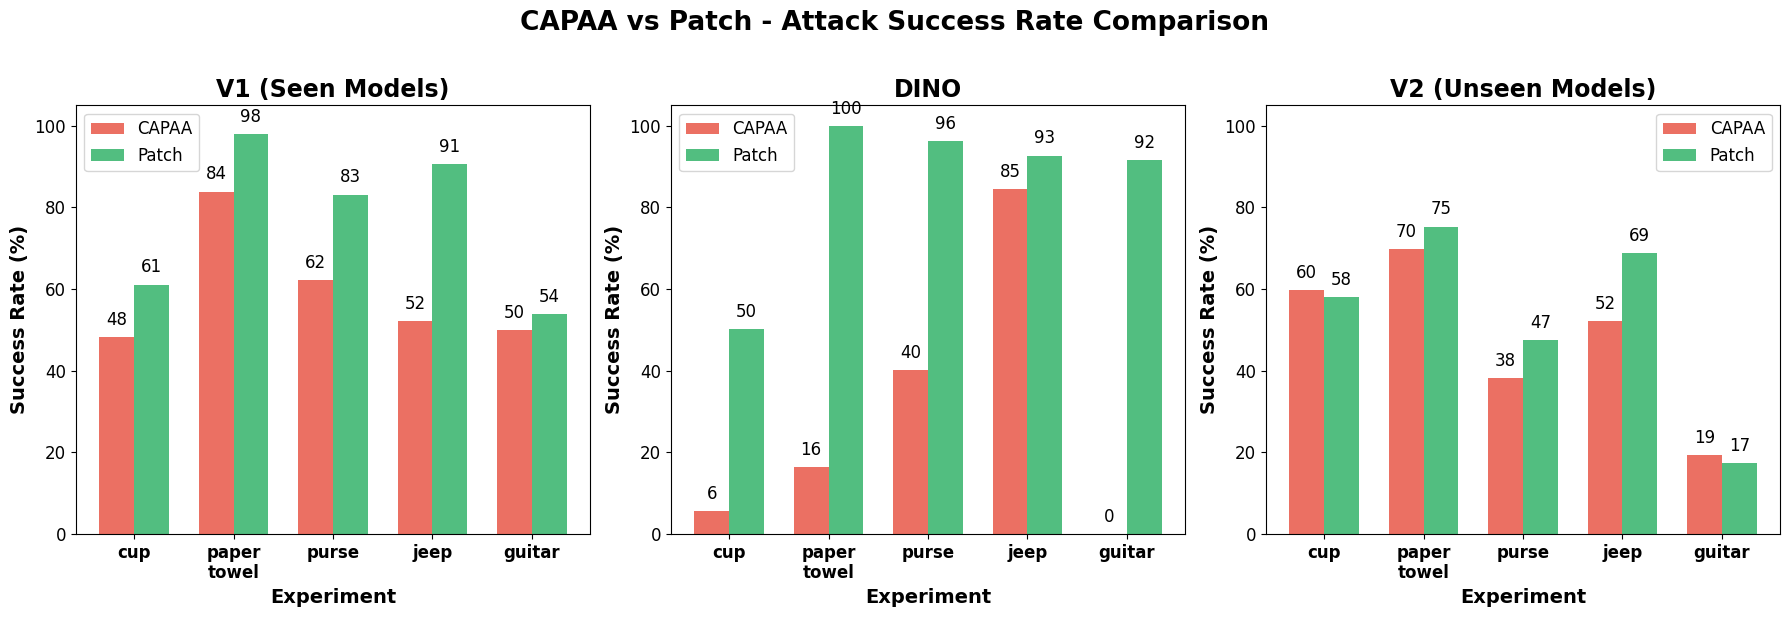

Comparison chart saved to: C:\git\PhysicalAdverserialProj\total_experiments_analysis\capaa_vs_patch_comparison.png
SVG saved to: C:\git\PhysicalAdverserialProj\total_experiments_analysis\paper_figures\capaa_vs_patch_comparison.svg


In [14]:
# Bar chart comparison: CAPAA vs Patch (PAPER VERSION with larger fonts)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

groups = ['V1-Avg', 'DINO', 'V2-Avg']
group_titles = ['V1 (Seen Models)', 'DINO', 'V2 (Unseen Models)']

experiments = list(comparison_df['Experiment'])
x = np.arange(len(experiments))
width = 0.35

for idx, (group, title) in enumerate(zip(groups, group_titles)):
    ax = axes[idx]
    
    capaa_vals = comparison_df[f'CAPAA {group}'].values
    patch_vals = comparison_df[f'Patch {group}'].values
    
    bars1 = ax.bar(x - width/2, capaa_vals, width, label='CAPAA', color='#e74c3c', alpha=0.8)
    bars2 = ax.bar(x + width/2, patch_vals, width, label='Patch', color='#27ae60', alpha=0.8)
    
    ax.set_xlabel('Experiment', fontweight='bold', fontsize=14)
    ax.set_ylabel('Success Rate (%)', fontweight='bold', fontsize=14)
    ax.set_title(title, fontsize=17, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([e.replace('_', '\n') for e in experiments], rotation=0, fontsize=12, fontweight='bold')
    ax.tick_params(axis='y', labelsize=12)
    ax.legend(fontsize=12)
    ax.set_ylim(0, 105)
    
    # Add value labels
    for bar in bars1:
        if not np.isnan(bar.get_height()):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
                   f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=12)
    for bar in bars2:
        if not np.isnan(bar.get_height()):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
                   f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=12)

plt.suptitle('CAPAA vs Patch - Attack Success Rate Comparison', fontsize=19, fontweight='bold', y=1.02)
plt.tight_layout()
# Save as both PNG and SVG
plt.savefig(os.path.join(BASE_PATH, 'capaa_vs_patch_comparison.png'), dpi=150, bbox_inches='tight')
plt.savefig(os.path.join(PAPER_FIGURES_PATH, 'capaa_vs_patch_comparison.svg'), format='svg', bbox_inches='tight')
plt.show()

print(f"Comparison chart saved to: {os.path.join(BASE_PATH, 'capaa_vs_patch_comparison.png')}")
print(f"SVG saved to: {os.path.join(PAPER_FIGURES_PATH, 'capaa_vs_patch_comparison.svg')}")